<a href="https://colab.research.google.com/github/JLettsSJU931/Machine-Learning-FA26/blob/main/HW2/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
#Load the dataset into a Pandas DataFrame.
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

df = pd.read_csv('cybersecurity_intrusion_data.csv')
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [70]:
#Use structural inspection methods (head(), info(), describe()) to analyze features such as network_packet_size, session_duration, login_attempts, protocol_type, and browser_type.
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [71]:
#Drop any non-informative identifiers.
df = df.drop(columns=['session_id'])
df.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [72]:
#Quantify any missing values across the columns
df.isna().sum()

,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,1966
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0
attack_detected,0


In [73]:
#Implement a structured imputation strategy (using Pandas or Scikit-Learn's SimpleImputer) to handle missing entries.
df['encryption_used'] = df['encryption_used'].fillna('Unknown')
df.isna().sum()

,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,0
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0
attack_detected,0


In [107]:
#Isolate numerical and categorical features,
#then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (e.g., StandardScaler) to numerical columns and encoding (e.g., OneHotEncoder) to categorical columns.
num_df = df.select_dtypes(include='number')
num_df_list = list(df.select_dtypes(include='number'))
item_df = df.select_dtypes(exclude='number')
item_df_list = list(df.select_dtypes(exclude='number'))
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler()),
])
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_df_list),
    ("cat", OneHotEncoder(), item_df_list),
])
df_prepared = full_pipeline.fit_transform(df)
print(df_prepared)

[[ 0.49689911 -0.01634592 -0.38112504 ...  0.          0.
   0.        ]
 [-0.14332201 -0.52579383  0.97295964 ...  1.          0.
   0.        ]
 [ 0.64813245 -0.52579383 -0.91250324 ...  0.          0.
   0.        ]
 ...
 [ 0.82457134  0.49310198 -0.96320007 ...  1.          0.
   0.        ]
 [-0.47603535 -0.01634592 -0.89772872 ...  0.          0.
   0.        ]
 [-0.80874869  1.00254989 -0.89745912 ...  0.          0.
   0.        ]]


In [118]:
#Compute the Pearson correlation matrix for the numerical features,
import seaborn as sns
import matplotlib.pyplot as plt
p_matrix = num_df.corr(method = 'pearson')
print("--- Pearson Correlation Matrix ---")
p_matrix

--- Pearson Correlation Matrix ---


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
network_packet_size,1.000000,-0.001890,0.021650,0.002320,-0.011676,-0.001255,-0.006798
login_attempts,-0.001890,1.000000,0.006392,-0.002618,-0.013507,0.007349,0.277320
session_duration,0.021650,0.006392,1.000000,-0.005077,0.019375,0.012930,0.041602
ip_reputation_score,0.002320,-0.002618,-0.005077,1.000000,0.015613,-0.003146,0.211540
failed_logins,-0.011676,-0.013507,0.019375,0.015613,1.000000,0.006131,0.363726
unusual_time_access,-0.001255,0.007349,0.012930,-0.003146,0.006131,1.000000,0.008652
attack_detected,-0.006798,0.277320,0.041602,0.211540,0.363726,0.008652,1.000000


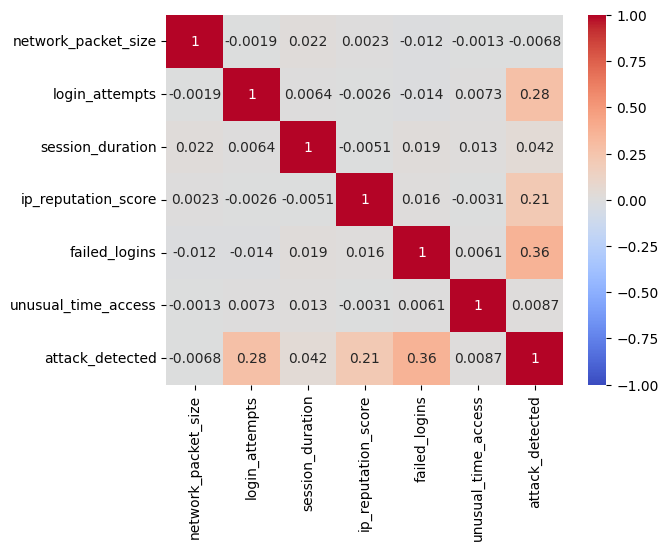

In [120]:
#generate a Seaborn heatmap with annotations,
sns.heatmap(p_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

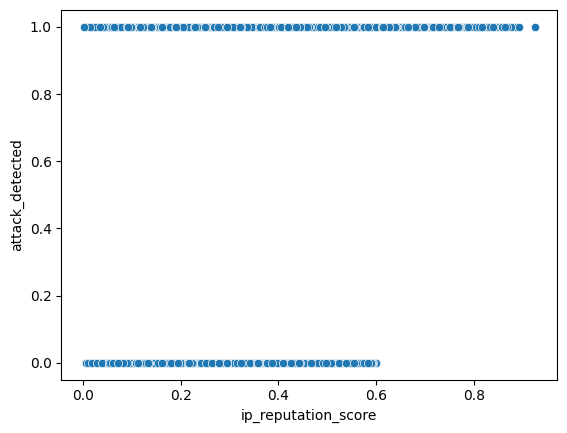

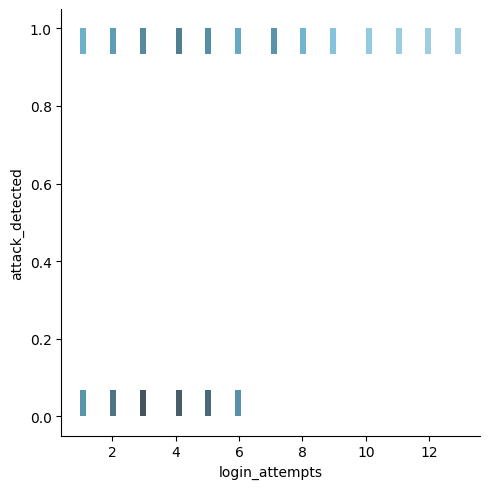

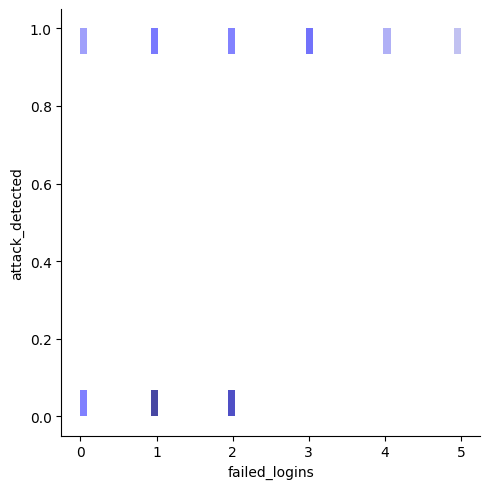

In [131]:
#and create at least two distribution plots and one scatter plot to examine feature relationships and the target variable (attack_detected).
sns.scatterplot(x=num_df['ip_reputation_score'], y=num_df['attack_detected'])
plt.show()
sns.displot(x=num_df['login_attempts'], y=num_df['attack_detected'], color="skyblue")
sns.displot(x=num_df['failed_logins'], y=num_df['attack_detected'], color="blue")